#TODO

- Work in the names method to extract better info
    - Pair with birthday
- Ocurrence of boxes (types)
- Date % missings 


In [2]:
import polars as pl
import altair as alt
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import json
import jellyfish
alt.data_transformers.enable("vegafusion")

DataTransformerRegistry.enable('vegafusion')

In [41]:
#Log files
root = Path('..')
#parquet_log = root / 'data/jails-data/output/processing_logs.parquet'
parquet_log = root / 'data/jails-data/SERVER/new run/output/processing_logs_full.parquet'
logs_df = pl.read_parquet(parquet_log)
logs_summary = (
    logs_df
    .group_by("status")
    .len()
    .with_columns([
        (pl.col("len") / pl.col("len").sum() * 100).round(1).alias("Percentage")
    ])
    .sort("len", descending=True)
    .rename({"len": "Count"})
    .select(["status", "Count", "Percentage"])
)

print("## Processing Status Summary\n")
with pl.Config(
    tbl_formatting="MARKDOWN",
    tbl_hide_column_data_types=True,
    tbl_hide_dataframe_shape=True,):
    print(logs_summary)

total_processed = logs_df.height
print(f"\n**Total Documents Processed:** {total_processed:,}")


## Processing Status Summary

| status  | Count | Percentage |
|---------|-------|------------|
| success | 27682 | 99.2       |
| failed  | 210   | 0.8        |

**Total Documents Processed:** 27,892


In [42]:
logs_df

pdf_name,page_number,page_id,status,error_stage,error_message
str,i64,str,str,str,str
"""Barber, Floyd 1-5""",1,"""Barber, Floyd 1-5_p1""","""failed""","""preprocessing""","""Image preprocessing returned N…"
"""Kiger, Bonham 1-2""",1,"""Kiger, Bonham 1-2_p1""","""success""","""""",""""""
"""Mateos, Gustavo 1-14""",1,"""Mateos, Gustavo 1-14_p1""","""success""","""""",""""""
"""Sinclair, Wendell 1-18""",1,"""Sinclair, Wendell 1-18_p1""","""success""","""""",""""""
"""Searle, Robert 1-21""",1,"""Searle, Robert 1-21_p1""","""success""","""""",""""""
…,…,…,…,…,…
"""UO - FOIA January 2023""",611,"""UO - FOIA January 2023_p611""","""success""","""""",""""""
"""UO - FOIA January 2023""",612,"""UO - FOIA January 2023_p612""","""success""","""""",""""""
"""UO - FOIA January 2023""",613,"""UO - FOIA January 2023_p613""","""success""","""""",""""""


### **Handwritten analysis** 

How many of them are handwritten?

First, we look at the distribution generated by the process:

In [3]:
root = Path('..')
#parquet_path = root / 'data/jails-data/output/jails_pdfs.parquet'
parquet_path = root / 'data/jails-data/SERVER/new run/output/jails_pdfs_full.parquet'
df = pl.read_parquet(parquet_path)

In [50]:
df

Deceased Name,Deceased Cause,Deceased Date and Time,Deceased on Suicide Watch,Deceased Reporter,Deceased Examined by Physician,Deceased Signs of Illness,Facility Type,RD Number,Facility Name,Phone Number,Address,Date,Time of Day,AM or PM,Occurrence,Table Contents,Injuries?,Resulting Death?,process,Report ID,OCR_Confidence,OCR_Word_Count,OCR_Text_Detected,Cook County?
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,list[str],list[str],str,str,str,str,f64,i64,bool,str
"""N/A""","""N/A""","""N/A""","""N/A""","""N/A""","""N/A""","""N/A""","""Error creating ROI: zero-lengt…","""R.D. Number: ; ""","""-acility Name: St. Clair Count…","""‘elephone #: 618-277-3505 ""","""\ddress: 700 North 5"" Street B…","""Date of Occurrence: 01/02/2021…","""me of Occurrence: 11:10 Oam. ""","""Error: less than two boxes fou…","[""Restraints Used —[ ""]","[""| 12/21/1995"", ""| 01/02/2021"", … ""Kiger, Bonham""]","""No injuries""","""No ""","""normal""","""Kiger, Bonham 1-2_p1""",87.941718,326,true,null
"""N/A""","""N/A""","""N/A""","""N/A""","""N/A""","""N/A""","""N/A""","""Error: less than two boxes fou…","""R.D. Number: 21-00542 | ""","""Facility Name: Lake County Jai…","""__ Telephone #: 847-377-4099 ""","""Address: 29 § Mlk Jr Ave Wauke…","""Date of Occurrence: 01/14/2021…","""_ Time of Occurrence: 12:23Pm ""","""p.m. ""","[""Other (specify): Resisted ""]","[""posse es"", ""_ Mateos, Gustavo"", … ""Robbery""]","""No injuries""","""Error: less than two boxes fou…","""normal""","""Mateos, Gustavo 1-14_p1""",88.17757,321,true,null
"""N/A""","""N/A""","""N/A""","""N/A""","""N/A""","""N/A""","""N/A""","""County ""","""R.D. Number: 21-00689 ""","""-acility Name: Lake County Jai…","""_.. Telephone #: 847-377-4099 ""","""\ddress: 29 S. Martin Luther K…","""Date of Occurrence: 01/18/2021…","""_ Time of Occurrence: 11:10 ""","""a.m, ""","[""DC Spray Used "", ""ther (specify): Disorderly C ""]","[""Sinclair, Wendell"", ""06/ 17/ 1996"", … ""| Retail then / Disp Merch""]","""No injuries""","""Error creating ROI: zero-lengt…","""normal""","""Sinclair, Wendell 1-18_p1""",89.354633,313,true,null
"""N/A""","""N/A""","""N/A""","""N/A""","""N/A""","""N/A""","""N/A""",""">| ""","""R.D.Number: ""","""Fax: (217) 522-3906 Facility N…","""__ Telephone #: 309-888-4628 ""","""Facility Name: McLean County J…","""Aqaress: 1U4 West rront sucer …","""pre AN EEN et City State Time …","""p.m. ""","[""Serious Iniury ""]","[""| METHAMPHETAMINE"", ""“12h 17/2020"", … ""| _TRAFFICKING _""]","""No injuries""","""No ""","""normal""","""Searle, Robert 1-21_p1""",88.421538,325,true,null
"""N/A""","""N/A""","""N/A""","""N/A""","""N/A""","""N/A""","""N/A""","""County ""","""R.D. Number: | ""","""Facility Name: Madison County …","""____ Telephone #: 618-692-1065…","""Address: 405 Randle Street Edw…","""Date of Occurrence: 01/06/2021…","""_ Time of Occurrence: 06:30 ""","""am ""","[""Restraints Used ""]","[""98/08/1983"", ""| 01/06/2021"", ""Sutton, Micah, Dawn""]","""No injuries""","""No ""","""normal""","""Sutton, Micah 1-6_p1""",90.006734,297,true,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""N/A""","""N/A""","""N/A""","""N/A""","""N/A""","""N/A""","""N/A""","""County ""","""LJ VINCAaAYyY FPUIULS MOVAGIUT…","""Facility Name: PEORIA COUNTY S…","""____—- Telephone #: 309-634-44…","""Address: 301 NMAXWELL RD PEORI…","""Street Date of Occurrence: 01/…","""City State _ Time of Occurrenc…","""No filled box found""","[""Other (specify): STATEMENTS ""]","[""HOWARD, ROBERT"", ""12/22/1974"", … ""TAZ CO HOLD""]","""No injuries""","""No ""","""reprocess""","""UO - FOIA January 2023_p611""",89.575163,306,true,null
"""N/A""","""N/A""","""N/A""","""N/A""","""N/A""","""N/A""","""N/A""","""County ""","""R.D. Number: 23-00936 ""","""Facility Name: Lake County She…","""___ Telephone #: (847) 377-409…","""Address: 29S. MLK Jr. Ave. Wau…","""Date of Occurrence: 01/31/2023…","""_ Time of Occurrence: 4:50 ""","""a.m. ""","[""OC Spray Used "", ""Dther (specify): Disorderly ""]","[""eat

In [51]:
ocr_histogram = alt.Chart(df).mark_bar().encode(
    x=alt.X('OCR_Confidence:Q', 
            bin=alt.Bin(maxbins=30),
            title='OCR Confidence Score'),
    y=alt.Y('count():Q', 
            title='Number of Documents'),
    color=alt.value("#7f95ad"),
    tooltip=[
        alt.Tooltip('OCR_Confidence:Q', bin=True, title='OCR Confidence Range'),
        alt.Tooltip('count():Q', title='Document Count')
    ]
).properties(
    width=600,
    height=400,
    title='Distribution of OCR Confidence Scores'
)

vertical_line = alt.Chart(df).mark_rule(
    color='red',
    strokeWidth=2,
    strokeDash=[5, 5]
).encode(
    x=alt.X('OCR_Confidence:Q', scale=alt.Scale(domain=[0, 100]))
).transform_calculate(
    OCR_Confidence='80'
)


ocr_histogram_with_line = ocr_histogram + vertical_line
ocr_histogram_with_line

alt.LayerChart(...)

Total documents with OCR Confidence < 80: 772


FileNotFoundError: [Errno 2] No such file or directory: '../data/jails-data/SERVER/new run/processed/FOIA - May 2024 UOs part 2_p315.png'

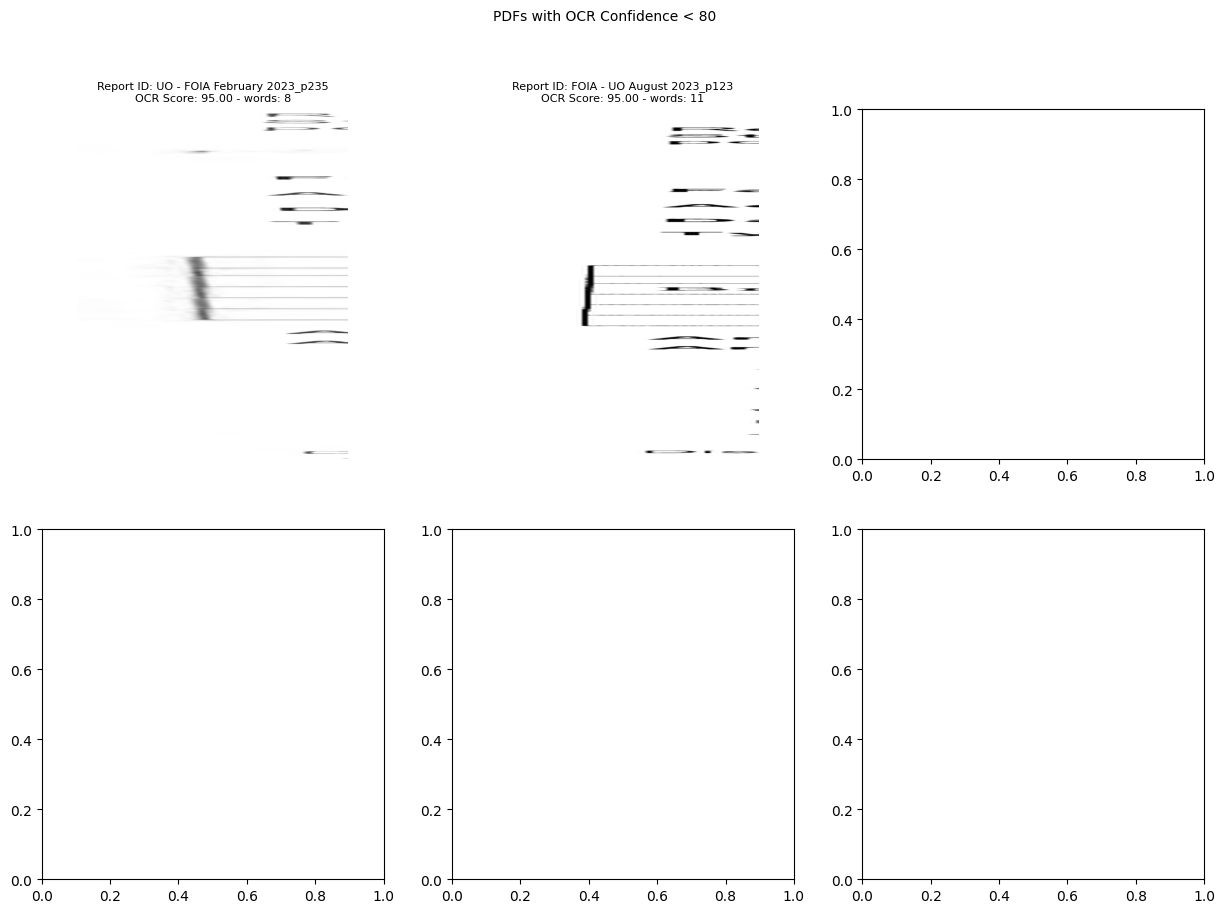

In [65]:
# show the least scores from the ones under 80:
low_ocr_reports = (
    df.filter(pl.col('OCR_Confidence')< 100)
    .select(['Report ID','OCR_Confidence', 'OCR_Word_Count'])
    .sort('OCR_Confidence', descending=True)
    .head(6)
)
# count numer of pages below that
total_pages_threshold = df.filter(pl.col('OCR_Confidence') < 80).height
print(f"Total documents with OCR Confidence < 80: {total_pages_threshold}")
# Folder with images
processed_folder = Path('..') / 'data/jails-data/SERVER/new run/processed'
# Set up the figure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('PDFs with OCR Confidence < 80', fontsize=10)

axes = axes.flatten()

for i, row in enumerate(low_ocr_reports.rows()):
    report_id = row[0]
    ocr_score = row[1]
    word_count = row[2]
    img_path = processed_folder / f"{report_id}.png"
    
    pil_image = Image.open(img_path)
    axes[i].imshow(pil_image)
    axes[i].set_title(f'Report ID: {report_id}\nOCR Score: {ocr_score:.2f} - words: {word_count}', fontsize = 8)
    axes[i].axis('off')
for i in range(len(low_ocr_reports), 6):
    axes[i].axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# Distribution of words:


In [53]:
# Clean facility name:
def clean_facility_name(df):
    """Clean facility names using Polars expressions"""
    return df.with_columns(
        pl.col('Facility Name')
        # First, clean OCR artifacts
        .str.replace_all(r'\\n|\\\\|\\/', ' ') 
        .str.replace_all(r'\n', ' ')
        .str.replace_all(r'[\\\/]+', ' ')
        .str.replace_all(r'\s+', ' ') 
        .str.strip_chars()
        # Extract facility name after any variation of "Name:"
        .str.extract(r'cility Name:\s*(.+)', 1)
        # Additional cleanup of extracted names
        .str.replace_all(r'[^a-zA-Z\s\'-]', ' ')  # Keep only letters, spaces, apostrophes, hyphens
        .str.replace_all(r'\s+', ' ')  # Clean multiple spaces again
        .str.strip_chars()  # Final trim
        # Stop at any word ending in "ddres" and remove that word + everything after
        .str.replace_all(r'\s+(ddress|ddrace).*$', '')
        .str.replace_all(r"(?i)\bSheriff's\b", "Sheriffs")
        .str.to_titlecase()
        .alias('Cleaned Facility Name')
    )

# Apply the cleaning
df_cleaned = clean_facility_name(df)
df_cleaned['Facility Name', 'Cleaned Facility Name']

Facility Name,Cleaned Facility Name
str,str
"""-acility Name: St. Clair Count…","""St Clair County Sheriffs Depar…"
"""Facility Name: Lake County Jai…","""Lake County Jail"""
"""-acility Name: Lake County Jai…","""Lake County Jail"""
"""Fax: (217) 522-3906 Facility N…","""Mclean County Jail"""
"""Facility Name: Madison County …","""Madison County Sheriffs Office"""
…,…
"""Facility Name: PEORIA COUNTY S…","""Peoria County Sheriffs Office"""
"""Facility Name: Lake County She…","""Lake County Sheriffs Office"""
"""-acility Name: Lake County Jai…","""Lake County Jail"""


In [54]:
# Missing info on facility name
facility_stats = (
    df_cleaned
    .select([
        pl.len().alias('Total'),
        pl.col('Cleaned Facility Name').is_null().sum().alias('Missing'),
    ])
    .with_columns([
        (pl.col('Missing') / pl.col('Total') * 100).alias('Missing_Percent'),
        pl.lit('Cleaned Facility Name').alias('Field')
    ])
    .select(['Field', 'Total','Missing','Missing_Percent'])
)
print("## Facility Name Completeness\n")
with pl.Config(
    tbl_formatting="MARKDOWN",
    tbl_hide_column_data_types=True,
    tbl_hide_dataframe_shape=True,):
    print(facility_stats)

## Facility Name Completeness

| Field                 | Total | Missing | Missing_Percent |
|-----------------------|-------|---------|-----------------|
| Cleaned Facility Name | 27682 | 1257    | 4.540857        |


In [55]:
# Most common by facility name
top_facilities = (
    df_cleaned
    .filter(pl.col('Cleaned Facility Name').is_not_null())  # Remove null facility names
    .group_by('Cleaned Facility Name')
    .len()
    .sort('len', descending=True)
    .head(20)
    .rename({'len': 'Case Count'})
)

# Create the Altair chart
facilities_chart = alt.Chart(top_facilities).mark_bar().encode(
    x=alt.X('Case Count:Q', title='Number of Cases'),
    y=alt.Y('Cleaned Facility Name:N', sort='-x', title='Facility Name'),
    color=alt.value("#da746d"), 
    tooltip=[
        'Cleaned Facility Name:N', 
        alt.Tooltip('Case Count:Q', format=',d')
    ]
).properties(
    width=600,
    height=400,
    title='Top 20 Facilities by Number of Cases'
)

facilities_chart

alt.Chart(...)

In [56]:
# Date cleanning
def clean_date_occurrence(df):
    return df.with_columns(
        pl.col("Date")
          # OCR cleanup (keep forward slashes)
          .str.replace_all(r"\\n|\\\\", " ")
          .str.replace_all(r"\n", " ")
          .str.replace_all(r"\s+", " ")
          .str.strip_chars()
          # Extract the MM/DD/YYYY text
          .str.extract(r"Date of Occurrence:\s*([0-9]{1,2}/[0-9]{1,2}/(20[0-9]{2}))", 1)
          # Parse & re‐format to zero‐padded MM/DD/YYYY
          .str.strptime(pl.Date, "%m/%d/%Y", strict=False)
          .alias("temp_date")
    ).with_columns(
        # Only keep dates between 2000 and 2025, otherwise set to null
        pl.when(pl.col("temp_date").dt.year().is_between(2000, 2025))
        .then(pl.col("temp_date").dt.strftime("%m/%d/%Y"))
        .otherwise(None)
        .alias("Cleaned Date")
    ).drop("temp_date")

df_cleaned = clean_date_occurrence(df_cleaned)
df_cleaned.select(["Date","Cleaned Date"]).head(10)

Date,Cleaned Date
str,str
"""Date of Occurrence: 01/02/2021…","""01/02/2021"""
"""Date of Occurrence: 01/14/2021…","""01/14/2021"""
"""Date of Occurrence: 01/18/2021…","""01/18/2021"""
"""Aqaress: 1U4 West rront sucer …",null
"""Date of Occurrence: 01/06/2021…","""01/06/2021"""
"""Date of Occurrence: 01/24/2021…","""01/24/2021"""
"""Date of Occurrence: 01/16/2021…","""01/16/2021"""
"""Date of Occurrence: 01/09/2021…","""01/09/2021"""
"""Date of Occurrence: 01/06/2021…","""01/06/2021"""


In [58]:
nulls = df_cleaned.filter(pl.col('Cleaned Date').is_null())

In [59]:
nulls = nulls[['Date','Cleaned Date']]

In [60]:
nulls

Date,Cleaned Date
str,str
"""Aqaress: 1U4 West rront sucer …",null
"""Date of Occurrence: 24 JANUARY…",null
"""Date of Occurrence: 06 JAN 202…",null
"""Aaaress. ( a Lin KT f= [Steet …",null
"""_ Date of Occurrence: f V4 . o…",null
…,…
"""Date of Occurrence: W27/12023—…",null
"""Date of Occurre: :e: 01/28/202…",null
"""Date of Occurrence: 9/30/23 """,null


In [33]:
df_cleaned[['Date','Cleaned Date']]

Date,Cleaned Date
str,str
"""AGaress. 14 West STORE SUCCL S…",null
"""Date of Occurrence: i/ (Z]2 ( …",null
"""Date of Occurrence: 01/26/2021…","""01/26/2021"""
"""Date of Occurrence: 01/19/2021…","""01/19/2021"""
"""Date of Occurrence: 01/26/2021…","""01/26/2021"""
…,…
"""Street Date of Occurrence: 01/…","""01/31/2023"""
"""Date of Occurrence: 01/31/2023…","""01/31/2023"""
"""Date of Occurrence: 01/31/2023…","""01/31/2023"""


In [57]:
# Calculate cleaned date completeness statistics
date_stats = (
    df_cleaned
    .select([
        pl.len().alias('Total'),
        pl.col('Cleaned Date').is_null().sum().alias('Missing'),
        pl.col('Cleaned Date').is_not_null().sum().alias('Present')
    ])
    .with_columns([
        (pl.col('Missing') / pl.col('Total') * 100).alias('Missing_Percent'),
        pl.lit('Cleaned Date').alias('Field')
    ])
    .select(['Field', 'Total', 'Missing', 'Missing_Percent'])
)

print("## Date Completeness\n")
with pl.Config(
    tbl_formatting="MARKDOWN",
    tbl_hide_column_data_types=True,
    tbl_hide_dataframe_shape=True,):
    print(date_stats)

## Date Completeness

| Field        | Total | Missing | Missing_Percent |
|--------------|-------|---------|-----------------|
| Cleaned Date | 27682 | 3512    | 12.686945       |


In [61]:
time_series_data = (
    df_cleaned
    .filter(pl.col('Cleaned Date').is_not_null())  # Remove null dates
    .with_columns(
        pl.col('Cleaned Date').str.to_date("%m/%d/%Y").alias('Date_parsed')  # Convert to actual date
    )
    .filter(pl.col('Date_parsed').dt.year().is_between(2018, 2024)) 
    .with_columns(
        pl.col('Date_parsed').dt.truncate('1mo').alias('Month')
    )
    .group_by('Month')
    .len()
    .sort('Month')
    .rename({'len': 'Case Count'})
)

# Create the time series chart
time_series_chart = alt.Chart(time_series_data).mark_line(
    point=True,
    strokeWidth=2
).encode(
    x=alt.X('Month:T', 
            title='Date of Occurrence',
            axis=alt.Axis(format='%b %Y')  # Format as "Jan 2021"
    ),
    y=alt.Y('Case Count:Q', 
            title='Number of Cases'
    ),
    color=alt.value("#50a0d9"),
    tooltip=[
        alt.Tooltip('Month:T', format='%B %d, %Y', title='Date'),
        alt.Tooltip('Case Count:Q', title='Cases')
    ]
).properties(
    width=700,
    height=400,
    title='Cases Over Time - Date of Occurrence'
)

time_series_chart

alt.Chart(...)

In [62]:
# Missing Months from 2018 to 2024 by Facility name:
facility_coverage = (
    df_cleaned
    .filter(
        pl.col('Cleaned Date').is_not_null() &
        pl.col('Cleaned Facility Name').is_not_null()
    )
    .with_columns(
        pl.col('Cleaned Date').str.to_date("%m/%d/%Y").alias('Date_parsed')
    )
    .filter(pl.col('Date_parsed').dt.year().is_between(2018, 2024))
    .with_columns(
        pl.col('Date_parsed').dt.truncate('1mo').alias('Month_Year')
    )
    .group_by(['Cleaned Facility Name', 'Month_Year'])
    .len()
    .group_by('Cleaned Facility Name')
    .agg([
        pl.col('Month_Year').n_unique().alias('Months_With_Data'),
        pl.col('len').sum().alias('Total_Records')
    ])
    .sort(['Months_With_Data', 'Total_Records'], descending=True)
)

print("## Facility Coverage Analysis (2018-2024)\n")
print("**Top 20 Facilities by Month Coverage**\n")
with pl.Config(
    tbl_formatting="MARKDOWN",
    tbl_hide_column_data_types=True,
    tbl_hide_dataframe_shape=True,
    tbl_rows=100):
    print(facility_coverage.head(20))


facility_coverage.write_excel('../data/jails-data/output/facility_coverage.xlsx')


## Facility Coverage Analysis (2018-2024)

**Top 20 Facilities by Month Coverage**

| Cleaned Facility Name           | Months_With_Data | Total_Records |
|---------------------------------|------------------|---------------|
| Lake County Jail                | 81               | 1792          |
| Madison County Sheriffs Office  | 81               | 1244          |
| Sangamon County Jail            | 80               | 777           |
| Lake County Adult Corrections   | 79               | 436           |
| Kane County Sheriffs Office     | 77               | 1486          |
| Peoria County Sheriffs Office   | 74               | 974           |
| Macon County Jail               | 74               | 328           |
| Sangamon County Adult Detentio… | 73               | 297           |
| Dupage County Jail              | 71               | 409           |
| Williamson County Jail          | 67               | 223           |
| Rock Island County Sheriffs Of… | 65               | 177      

In [105]:
ocr_histogram_with_line.save('../presentations/images/ocr_distribution.png', scale_factor=2)
facilities_chart.save('../presentations/images/top_facilities.png', scale_factor=2)
time_series_chart.save('../presentations/images/cases_over_time.png', scale_factor=2)


In [64]:
def clean_occurrences(entries):
    actual_occurrences = ["Suicide (method)", "Suicide (attempt)", "Homicide", "Homicide Attempt", "Escape", "Escape Attempt",
                "Fire", "Serious Injury", "Battery", "Riot of Rebellion", "Sex Offense", "Assault on Staff",
                "Assault among Detainees", "Fighting among Detainees", "Restraints Used", "OC Spray Used", "Other (specify)"]
    
    if len(entries) == 0:  # Fixed: Python lists don't have is_empty()
        return ["Error, no occurrence found"]

    cleaned_list = []
    for term in entries:
        best_choice = None
        highest_jaro = 0.0
        for compare_term in actual_occurrences:
            jaro_score = jellyfish.jaro_similarity(term, compare_term)
            if jaro_score > highest_jaro:
                highest_jaro = jaro_score
                best_choice = compare_term

        if best_choice in ["Suicide (method)", "Suicide (attempt)", "Other (specify)"]:
            cleaned_list.append(term)
        else:
            if best_choice not in cleaned_list:
                cleaned_list.append(best_choice)

    return cleaned_list

# Updated to use map_batches instead of deprecated map_elements
samples_df = df_cleaned.with_columns(pl.col("Occurrence").map_elements(clean_occurrences, return_dtype=pl.List(pl.String)).alias("Cleaned Occurrences"))


In [69]:
samples_df[['Cleaned Occurrences']]

Cleaned Occurrences
str
"""Error, no occurrence found"""
"""Suicide Attempt (method) Drink…"
"""Error, no occurrence found"""
"""Restraints Used,Assault on Sta…"
"""ther (specify): Sick Person """
…
"""Battery"""
"""Fighting among Detainees"""
"""Fighting among Detainees"""


In [66]:
samples_df = samples_df.drop(["OCR_Confidence", "OCR_Word_Count", "OCR_Text_Detected", "Occurrence", "Facility Name", "Date", "Cook County?"])

In [67]:
samples_df = samples_df.with_columns(pl.col("Cleaned Occurrences").list.join(",").alias("Cleaned Occurrences"))

In [71]:
samples_df = samples_df.select(["Report ID", "Facility Type", "Cleaned Facility Name", "Address", "Phone Number", "Cleaned Date", "Time of Day", "AM or PM", "Table Contents", "Cleaned Occurrences", "Injuries?", "Resulting Death?", 'Deceased Cause, Date, and Time', 'Deceased on Suicide Watch', 'Deceased Reporter', 'Deceased Examined by Physician', 'Deceased Signs of Illness'])

In [73]:
samples_df = samples_df.with_columns(
    pl.when(pl.col("Cleaned Occurrences") == "")
    .then(pl.lit("Error, no occurrence found"))
    .otherwise(pl.col("Cleaned Occurrences"))
    .alias("Cleaned Occurrences")
)

def clean_other(df):
    pattern = r"specify"
    df = df.with_columns(
    pl.when(pl.col("Cleaned Occurrences").str.contains(pattern))
    .then(pl.col("Cleaned Occurrences").str.extract(r"specify(.*)", group_index=1))
    .otherwise(pl.col("Cleaned Occurrences"))
    .alias("Cleaned Occurrences")
    )

    return df

total_occurrence_result = (
    samples_df
    .with_columns(
        pl.col("Cleaned Occurrences").str.split(",").alias("Cleaned Occurrences")
    )
    .explode("Cleaned Occurrences")
    .filter(pl.col("Cleaned Occurrences").is_not_null())
    .select(
        pl.col("Cleaned Occurrences").value_counts(sort=True)
    )
    .unnest("Cleaned Occurrences")
    .head(12)
)

total_occurrence_result = clean_other(total_occurrence_result)

total_occurrence_result = total_occurrence_result.filter(~pl.col("Cleaned Occurrences").is_in(["Error", " no occurrence found"]))


In [77]:
total_occurrence_chart = alt.Chart(total_occurrence_result).mark_bar(
    color="#54728d"
).encode(
    x=alt.X('count:Q', title='Number of Cases'),
    y=alt.Y('Cleaned Occurrences:N', sort='-x', title='Occurrence'),
    tooltip=[
        alt.Tooltip('Cleaned Occurrences:N', title='Occurrence'),
        alt.Tooltip('count:Q', format=',d', title='Case Count')
    ]
).properties(
    width=600,
    height=400,
    title='Most Common Occurrences Across All Jails'
)

# Footnote as a separate text chart (keep your note)
footnote = alt.Chart(pl.DataFrame({
    "text": ["Note: Occurrences may be concurrent. Missing 3,418 Occurrences (12.5%)"],
    "x": [0],
    "y": [0]
})).mark_text(
    align="left",
    baseline="bottom",
    fontSize=10,
    dx=0,
    dy=20,
    color="gray"
).encode(
    x=alt.value(-50),
    y=alt.value(440),
    text="text:N"
)

# Layer chart and footnote, remove box
total_occurrence_chart = alt.layer(
    total_occurrence_chart,
    footnote
).configure_view(
    stroke=None
)

total_occurrence_chart

alt.LayerChart(...)

In [ ]:
samples_df[['Cleaned Occurrences']]

In [79]:
pattern = r"\bspecify\b"

other_occurrence_table = samples_df.filter(
    pl.col("Cleaned Occurrences").str.contains(pattern)
)
    
other_occurrence_table = clean_other(other_occurrence_table)

other_occurrence_table = (
    other_occurrence_table.select(
        pl.col("Cleaned Occurrences").value_counts(sort=True)
    )
    .unnest("Cleaned Occurrences")
    .head(10)
)

other_occurrence_chart = alt.Chart(other_occurrence_table).mark_bar(
    color="#da746d"
).encode(
    x=alt.X("count:Q", title="Count"),
    y=alt.Y("Cleaned Occurrences:N", title="Occurrence", sort='-x'),
    tooltip=[
        alt.Tooltip("Cleaned Occurrences:N", title="Occurrence"),
        alt.Tooltip("count:Q", format=",d", title="Case Count")
    ]
).properties(
    width=600,
    height=400,
    title="Most Common Other Occurrences Across All Jails"
)
other_occurrence_chart

alt.Chart(...)

In [81]:
top_counties = (
    samples_df
    .select(["Cleaned Facility Name", "Cleaned Occurrences"])
    .with_columns(
        pl.col("Cleaned Occurrences").str.split(",").alias("Cleaned Occurrences")
    )
    .explode("Cleaned Occurrences")
    .with_columns(
        pl.col("Cleaned Occurrences").str.strip_chars().alias("Cleaned Occurrences")
    )
    .filter(pl.col("Cleaned Occurrences").is_not_null())
)

def get_county_occurrences(current_jail):
    filtered_df = top_counties.filter(pl.col("Cleaned Facility Name") == current_jail)
    current_jail_result = (
    filtered_df.select(
        pl.col("Cleaned Occurrences").value_counts(sort=True)
    )
    .unnest("Cleaned Occurrences")
    .head(12)
    )
    current_jail_result = current_jail_result.filter(~pl.col("Cleaned Occurrences").is_in(["Error", "no occurrence found"]))
    current_jail_chart = alt.Chart(current_jail_result).mark_bar(
    color="#54728d").encode(
    x=alt.X('count:Q', title='Number of Cases'),
    y=alt.Y('Cleaned Occurrences:N', sort='-x', title='Occurrence'),
    tooltip=[
        alt.Tooltip('Cleaned Occurrences:N', title='Occurrence'),
        alt.Tooltip('count:Q', format=',d', title='Case Count')
    ]
    ).properties(
    width=600,
    height=400,
    title=current_jail
    )
    return current_jail_chart

cook_county = get_county_occurrences("Cook County Department Of Corrections")

kane_county = get_county_occurrences("Kane County Sheriffs Office")

madison_county = get_county_occurrences("Madison County Sheriffs Office")

In [82]:
cook_county

alt.Chart(...)

In [83]:
kane_county

alt.Chart(...)

In [84]:
madison_county

alt.Chart(...)

In [86]:
pattern = r"\bRestraints\b"

restraints_table = samples_df.filter(
    pl.col("Cleaned Occurrences").str.contains(pattern)
)

restraints_table = (
    restraints_table.select(
        pl.col("Cleaned Facility Name").value_counts(sort=True)
    )
    .unnest("Cleaned Facility Name")
    .head(21)
)

restraints_table = restraints_table.filter(pl.col("Cleaned Facility Name") != "")

restraints_chart = alt.Chart(restraints_table).mark_bar(
    color="#5a8664").encode(
    x=alt.X("count:Q", title="Count"),
    y=alt.Y("Cleaned Facility Name:N", title="Jail").sort('-x'),
    tooltip=[
        alt.Tooltip("Cleaned Facility Name:N", title="Jail"),
        alt.Tooltip("count:Q", format=",d", title="Case Count")
    ]
).properties(
    width=600,
    height=400,
    title="Top Jails for Restraint Usage"
)

# Footnote as a separate text chart
footnote = alt.Chart(pl.DataFrame({
    "text": ["Note: Missing 214 Jail Names (12%)"],
    "x": [0],
    "y": [0]
})).mark_text(
    align="left",
    baseline="bottom",
    fontSize=10,
    dx=0,
    dy=20,  # distance below the main chart area
    color="gray"
).encode(
    x=alt.value(0),
    y=alt.value(440),  # just below the chart (chart height + some offset)
    text="text:N"
)

# Use layering to draw the footnote over/under the chart
restraints_chart = alt.layer(
    restraints_chart,
    footnote
).configure_view(
    stroke=None  # removes box around the chart
)

restraints_chart

alt.LayerChart(...)

In [92]:
restraints_table = restraints_table.filter(pl.col("Cleaned Facility Name") != "null").join(top_counties, on="Cleaned Facility Name")

restraints_table

Cleaned Facility Name,count,Cleaned Occurrences,Cleaned Occurrences_right
str,u32,str,str
"""Kane County Sheriffs Office""",686,"""Suicide Attempt (method) Drink…","""Suicide Attempt (method) Drink…"
"""Kane County Sheriffs Office""",686,"""Other (specify): Rest Chair""","""Suicide Attempt (method) Drink…"
"""Kane County Sheriffs Office""",686,"""Restraints Used""","""Suicide Attempt (method) Drink…"
"""Kane County Sheriffs Office""",686,"""Restraints Used""","""Suicide Attempt (method) Drink…"
"""Kane County Sheriffs Office""",686,"""Fighting among Detainees""","""Suicide Attempt (method) Drink…"
…,…,…,…
"""St Clair County Sheriffs Depar…",89,"""Other (specify): Response to R…","""Other (specity): Chair"""
"""St Clair County Sheriffs Depar…",89,"""Restraints Used""","""Other (specity): Chair"""
"""St Clair County Sheriffs Depar…",89,"""Other (specity): Chair""","""Other (specity): Chair"""


In [93]:
restraints_perc_chart = alt.Chart(
    restraints_table.filter(pl.col("count_right") >= 100).with_columns(
        (pl.col("count") / pl.col("count_right") * 100).alias("perc")
    )
).mark_bar(
    color="#da746d"
).encode(
    x=alt.X("perc:Q", title="Percentage"),
    y=alt.Y("Cleaned Facility Name:N", title="Jail", sort='-x'),
    tooltip=[
        alt.Tooltip("Cleaned Facility Name:N", title="Jail"),
        alt.Tooltip("perc:Q", format=".1f", title="Percent")
    ]
).properties(
    width=600,
    height=400,
    title="Top Jails for Restraint Usage as a Percent of Reports"
)

# Footnote below the x-axis
footnote = alt.Chart(pl.DataFrame({
    "text": ["Note: Only Jails with over 100 Reports Total"],
    "x": [0],
    "y": [0]
})).mark_text(
    align="left",
    baseline="top",
    fontSize=10,
    dx=0,
    dy=0,
    color="gray"
).encode(
    x=alt.value(0),
    y=alt.value(440),  # 400 (chart height) + 40 for padding
    text="text:N"
)

# Layer chart and footnote, remove box
restraints_perc_chart = alt.layer(
    restraints_perc_chart,
    footnote
).configure_view(
    stroke=None
)

restraints_perc_chart

ColumnNotFoundError: unable to find column "count_right"; valid columns: ["Cleaned Facility Name", "count", "Cleaned Occurrences", "Cleaned Occurrences_right"]

In [ ]:
pattern = r"\bFighting among Detainees\b"

fighting_table = samples_df.filter(
    pl.col("Cleaned Occurrences").str.contains(pattern)
)

fighting_table = (
    fighting_table.select(
        pl.col("Cleaned Facility Name").value_counts(sort=True)
    )
    .unnest("Cleaned Facility Name")
    .head(21)
)

fighting_table = fighting_table.filter(pl.col("Cleaned Facility Name") != "null").join(top_counties, on="Cleaned Facility Name")

fighting_chart = alt.Chart(fighting_table).mark_bar().encode(
    x=alt.X("count:Q", title="Count"),
    y=alt.Y("Cleaned Facility Name:N", title="Jail").sort('-x')
).properties(
    title="Top Jails for Fighting among Detainees Usage"
)

# Footnote as a separate text chart
footnote = alt.Chart(pl.DataFrame({
    "text": ["Note: Missing 214 Jail Names (12%)"],
    "x": [0],
    "y": [0]
})).mark_text(
    align="left",
    baseline="bottom",
    fontSize=10,
    dx=0,
    dy=20,  # distance below the main chart area
    color="gray"
).encode(
    x=alt.value(0),
    y=alt.value(430),  # just below the chart (chart height + some offset)
    text="text:N"
)

# Use layering to draw the footnote over/under the chart
fighting_chart = alt.layer(
    fighting_chart,
    footnote
).configure_view(
    stroke=None  # removes box around the chart
)

fighting_chart

In [9]:
contents = df_cleaned['Table Contents']

In [12]:
contents.head()

Table Contents
list[str]
"[""WELIIIC CS WIVOlVEU"", ""wae eee"", … ""PATOS teria sams""]"
"[""Cross, Anton Nelson"", ""| 02/04/1999"", … ""Murder 1*, Agg Battery""]"
"[""vee ence"", ""Webster, Tiffany"", … ""ee a __""]"
"["". 01/14/2021"", ""Yvette Magana"", … ""oe ee""]"
"[""-10n8/ 1984"", ""09/25/20 | a"", … """"Hut, Anthony L160833""]"
"[""Agg tat (Horm [pov cel"", ""iatadee, tw cS"", … ""0 Der) € iesst/otstod off z""]"
"[""ey soe"", ""Madden, Lawrence L#170852"", … ""———————""]"
"[""METH DELIVERY/5<15 GRAMS"", ""Coffin, Andrew"", … ""o1/ 14/2021""]"
"[""07/15/1996"", ""Breanna Livingston"", … ""Disorderly Conduct""]"


In [13]:
contents[0]:
    

""
str
"""WELIIIC CS WIVOlVEU"""
"""wae eee"""
"""Keua >. | Saapsent"""
"""2 ahaa a"""
"""a pal se"""
""""" Arenee Hort ics"""
"""[Poste WvAso4"""
"""AGG him SEX. Assit"""
"""Ae bel pIvVAriie"""


In [16]:
type(df_cleaned['Table Contents'][10])

polars.series.series.Series

In [49]:
# names extraction statistics
for el in df_cleaned['Table Contents'][10]:
    print(el)

07/21/1980
01/21/2021
Swims, Keyran |
Out Of State Warrant


In [ ]:
from transformers import pipeline 

In [ ]:
class JailNameClassifier:
    def __init__(self):
        self.nlp = spacy.load("en_core_web_sm")
        self.ner_pipeline = pipeline("ner", 
                                   model="dbmdz/bert-large-cased-finetuned-conll03-english",
                                   aggregation_strategy="simple")
        
        # Common jail/legal terms that are NOT names
        self.exclude_terms = {
            # Charges
            'assault', 'battery', 'theft', 'burglary', 'dui', 'possession', 'murder',
            'robbery', 'fraud', 'trespass', 'violation', 'contempt', 'warrant',
            'felony', 'misdemeanor', 'charge', 'count', 'degree',
            
            # Locations/Facilities
            'county', 'jail', 'prison', 'detention', 'facility', 'center', 'office',
            'department', 'corrections', 'sheriff', 'police', 'court', 'division',
            
            # Administrative
            'booking', 'release', 'transfer', 'medical', 'incident', 'report',
            'occurrence', 'serious', 'injury', 'fighting', 'restraints', 'spray',
            
            # Common OCR errors
            'error', 'found', 'null', 'unknown', 'redacted', 'blank'
        }
        
        # Patterns that indicate NOT a name
        self.exclude_patterns = [
            r'\b\d+\b',  # Numbers
            r'[A-Z]{2,}\s[A-Z]{2,}',  # All caps (likely abbreviations)
            r'.*\d.*',  # Contains numbers
            r'^[A-Z]{1,3}$',  # Single letters or short abbreviations
            r'.*\s(County|Jail|Office|Department|Corrections)$',  # Ends with facility terms
            r'^(Serious|Fighting|Restraints|Error).*',  # Starts with incident terms
        ]
    
    def is_likely_name(self, text):
        """Pre-filter to determine if text could be a name"""
        if pd.isna(text) or text.strip() == "":
            return False
            
        text_lower = text.lower().strip()
        
        # Check exclude terms
        for term in self.exclude_terms:
            if term in text_lower:
                return False
        
        # Check exclude patterns
        for pattern in self.exclude_patterns:
            if re.search(pattern, text, re.IGNORECASE):
                return False
        
        # Basic name structure checks
        words = text.split()
        if len(words) < 1 or len(words) > 4:  # Names typically 1-4 words
            return False
            
        # Check if words look like names (start with capital, mostly letters)
        for word in words:
            if not re.match(r'^[A-Z][a-z]+$', word) and not re.match(r'^[A-Z]$', word):
                return False
        
        return True
    
    def classify_with_spacy(self, text):
        """Use spaCy for name classification"""
        doc = self.nlp(text)
        persons = []
        for ent in doc.ents:
            if ent.label_ == "PERSON":
                persons.append({
                    'name': ent.text,
                    'confidence': 0.8,  # spaCy doesn't provide confidence scores
                    'method': 'spacy'
                })
        return persons
    
    def classify_with_huggingface(self, text):
        """Use HuggingFace for name classification"""
        try:
            entities = self.ner_pipeline(text)
            persons = []
            for entity in entities:
                if entity['entity_group'] == 'PER':
                    persons.append({
                        'name': entity['word'].replace('##', ''),  # Clean tokenization artifacts
                        'confidence': entity['score'],
                        'method': 'huggingface'
                    })
            return persons
        except Exception as e:
            return []
    
    def classify_names(self, text_list):
        """Main classification function"""
        results = []
        
        for text in text_list:
            if not self.is_likely_name(text):
                results.append({
                    'original_text': text,
                    'is_name': False,
                    'reason': 'filtered_out',
                    'classifications': []
                })
                continue
            
            # Run both classifiers
            spacy_results = self.classify_with_spacy(text)
            hf_results = self.classify_with_huggingface(text)
            
            # Combine results
            all_classifications = spacy_results + hf_results
            
            # Determine final classification
            is_name = len(all_classifications) > 0
            
            results.append({
                'original_text': text,
                'is_name': is_name,
                'reason': 'classified' if is_name else 'no_person_entities',
                'classifications': all_classifications
            })
        
        return results

# Usage example for your data
classifier = JailNameClassifier()

# Your sample data
sample_texts = [
    "Malique D Clark",
    "Scott Timothy D",
    "Clinton Cou",  # Might be OCR error
    "Serious Injury,Fighting among",
    "Cook County Department Of Corrections",
    "OC Spray Used",
    "Kyle Wunderlich",
    "Error, no occurrence found"
]

results = classifier.classify_names(sample_texts)

# Display results
for result in results:
    print(f"Text: '{result['original_text']}'")
    print(f"Is Name: {result['is_name']}")
    print(f"Reason: {result['reason']}")
    if result['classifications']:
        for cls in result['classifications']:
            print(f"  - {cls['name']} (confidence: {cls['confidence']:.2f}, method: {cls['method']})")
    print("---")

END 

---

In [97]:
most_common = (df["Table Contents"]
               .explode()
               .value_counts()
               .sort("count", descending=True))

print("Most common Table Contents values:")
most_common.head(10)
#Cehck this

Most common Table Contents values:


Table Contents,count
str,u32
"""VMELAINESs VOW""",6358
"""VElLAINees VvOlIVea""",735
"""Vlas IMVOIVveg""",725
"""(J OC Spray Used""",563
"""Bad parse""",473
"""(1 Fighting among Detainees""",442
"""_] Fighting among Detainees""",424
"""VCldINees IVvVOIVeag""",397
"""(1) OC Spray Used""",374


In [ ]:
#clean_data = []
#for record in raw_data:
#    clean_record = {}
#    for key, value in record.items():
#        if isinstance(value, (dict, list)):
#            clean_record[key] = str(value) 
#        else:
#            clean_record[key] = value
#    clean_data.append(clean_record)


DataFrame has 110 rows and 17 columns
Saved to ../data/jails-data/output/jails_pdfs.parquet


In [98]:
key_fields_s1 = [
    'Facility Name',  'Phone Number', 'Date', 'Address'
]
key_fields_s2 = [
    'Facility Type', 'Time of Day', 'AM or PM'
]
key_fields_s3 = [
    'Table Contents'
]

def get_stats_by_section(sec: int =1):
    
    if sec == 1:
        fields = key_fields_s1
    elif sec == 2:
        fields = key_fields_s2
    elif sec == 3:
        fields = key_fields_s3
    stats = []
    total = df.height

    for field in fields:
        print(field)
        if sec == 3:
           missing_count = df.filter(
               pl.col(field).is_null() |
               (pl.col(field).is_not_null() & (pl.col(field).list.len() == 0))).height
        else: 
        # Count nulls, "N/A", "None", and empty strings
            missing_count = df.filter(
                pl.col(field).is_null() | 
                pl.col(field).eq("N/A") | 
                pl.col(field).eq("None") |
                pl.col(field).eq("")
            ).height
        
        stats.append({
            "Field": field,
            "Missing_Count": missing_count,
            "Missing_Percent": (missing_count / total) * 100,
            "Complete_Count": total - missing_count,
            "Complete_Percent": ((total - missing_count) / total) * 100
        })
        stats_df = pl.DataFrame(stats)
    return stats_df

# Convert stats to DataFrame
stats1 = get_stats_by_section(1)  
stats2 = get_stats_by_section(2)  
stats3 = get_stats_by_section(3)  
stats_df = pl.concat([
    stats1.with_columns(pl.lit("Basic Info").alias("Section")),
    stats2.with_columns(pl.lit("Secondary Info").alias("Section")),
    stats3.with_columns(pl.lit("Table Data").alias("Section"))
])

stats_df.sort("Missing_Percent", descending=True)


Facility Name
Phone Number
Date
Address
Facility Type
Time of Day
AM or PM
Table Contents


Field,Missing_Count,Missing_Percent,Complete_Count,Complete_Percent,Section
str,i64,f64,i64,f64,str
"""Address""",1720,6.29276,25613,93.70724,"""Basic Info"""
"""Facility Name""",766,2.802473,26567,97.197527,"""Basic Info"""
"""Date""",612,2.239052,26721,97.760948,"""Basic Info"""
"""Time of Day""",294,1.075623,27039,98.924377,"""Secondary Info"""
"""Facility Type""",248,0.907328,27085,99.092672,"""Secondary Info"""
"""Phone Number""",223,0.815864,27110,99.184136,"""Basic Info"""
"""Table Contents""",137,0.501226,27196,99.498774,"""Table Data"""
"""AM or PM""",98,0.358541,27235,99.641459,"""Secondary Info"""


In [11]:
missing_chart = alt.Chart(stats_df).mark_bar().encode(
    x=alt.X('Missing_Percent:Q', title='% Missing'),
    y=alt.Y('Field:N', sort='-x', title='Field'),
    color=alt.value('#e45756'),  # Red color for missing
    tooltip=['Field', 'Missing_Count', alt.Tooltip('Missing_Percent:Q', format='.1f')]
).properties(
    width=600,
    title='Percentage of Missing Values by Field'
)

missing_chart

alt.Chart(...)

In [13]:
# Create a stacked bar chart showing complete vs missing
stacked_df = stats_df.unpivot(
    index=["Field"], 
    on=["Complete_Percent", "Missing_Percent"],
    variable_name="Status", 
    value_name="Percentage"
)

# Clean up status names
stacked_df = stacked_df.with_columns(
    pl.col("Status").map_elements(lambda x: "Complete" if "Complete" in x else "Missing")
)

# Create stacked bar chart
stacked_chart = alt.Chart(stacked_df).mark_bar().encode(
    x=alt.X('Percentage:Q', title='Percentage (%)'),
    y=alt.Y('Field:N', title='Field'),
    color=alt.Color('Status:N', scale=alt.Scale(
        domain=['Complete', 'Missing'],
        range=["#94adc7", "#e87e7e"]
    )),
    tooltip=['Field', 'Status', alt.Tooltip('Percentage:Q', format='.1f')]
).properties(
    width=600,
    title='Completion Rate by Field'
)

stacked_chart

/var/folders/m8/p0y07mnx0xj8nxd8l9zj7fn00000gn/T/ipykernel_5420/2304937129.py:10: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  stacked_df = stacked_df.with_columns(


alt.Chart(...)